                  Projet : Température Terrestre

Partie 2 : Découverte et analyse des données
Le jeu de données contient 79 colonnes et 50191 lignes
Remplissage du template excel

In [ ]:
# Lecture de la donnée CO2
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/owid-co2-data.csv')
df.head()

# Recherche des types de chaque colonne
pd.set_option('display.max_rows', None) # Pour afficher toutes les lignes car notebook par défunt limite l'affichage des lignes
df_types = df.dtypes.reset_index()
df.dtypes.columns = ['Nom de colonne', 'Type de données'] # pour créer un tableau avec les colonnes et leur type
display(df_types)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,index,0
0,country,object
1,year,int64
2,iso_code,object
3,population,float64
4,gdp,float64
5,cement_co2,float64
6,cement_co2_per_capita,float64
7,co2,float64
8,co2_growth_abs,float64
9,co2_growth_prct,float64


In [ ]:
# Vérification présence de doublons
print(df[df.duplicated()])
# Le jeu de données ne présente aucun doublon

Empty DataFrame
Columns: [country, year, iso_code, population, gdp, cement_co2, cement_co2_per_capita, co2, co2_growth_abs, co2_growth_prct, co2_including_luc, co2_including_luc_growth_abs, co2_including_luc_growth_prct, co2_including_luc_per_capita, co2_including_luc_per_gdp, co2_including_luc_per_unit_energy, co2_per_capita, co2_per_gdp, co2_per_unit_energy, coal_co2, coal_co2_per_capita, consumption_co2, consumption_co2_per_capita, consumption_co2_per_gdp, cumulative_cement_co2, cumulative_co2, cumulative_co2_including_luc, cumulative_coal_co2, cumulative_flaring_co2, cumulative_gas_co2, cumulative_luc_co2, cumulative_oil_co2, cumulative_other_co2, energy_per_capita, energy_per_gdp, flaring_co2, flaring_co2_per_capita, gas_co2, gas_co2_per_capita, ghg_excluding_lucf_per_capita, ghg_per_capita, land_use_change_co2, land_use_change_co2_per_capita, methane, methane_per_capita, nitrous_oxide, nitrous_oxide_per_capita, oil_co2, oil_co2_per_capita, other_co2_per_capita, other_industry_co2

In [ ]:
# Calcul du taux de NA dans le df
na_serie = round((df.isna().sum()/len(df))*100,2)

# Transformation de la serie na_serie en DataFrame pour pouvoir l'exporter
na_df = na_serie.reset_index()
na_df.columns = ['Nom de colonne', 'Taux NA']
display(na_df)

,Nom de colonne,Taux NA
0,country,0.00
1,year,0.00
2,iso_code,15.80
3,population,18.27
4,gdp,69.61
5,cement_co2,42.49
6,cement_co2_per_capita,49.48
7,co2,41.95
8,co2_growth_abs,46.24
9,co2_growth_prct,48.19


In [ ]:
df["country"].unique()



array(['Afghanistan', 'Africa', 'Africa (GCP)', 'Albania', 'Algeria',
       'Andorra', 'Angola', 'Anguilla', 'Antarctica',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia',
       'Asia (GCP)', 'Asia (excl. China and India)', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda',
       'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Central America (GCP)', 'Chad',
       'Chile', 'China', 'Christmas Island', 'Colombia', 'Comoros',
       'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Domini

Le jeu de données étant très lourd car il contient des informations sur plusieurs types d'émission des gaz à effets de serres au niveau mondial, continet et par pays.
Le CO2 étant aujourd'hui la première cause du réchauffement climatique à l'échelle palnète. L'idée est de voir sa répartition par zone. Après faire une analyse sur la température afin de confirmer si le CO2 joue un role dans ce déréglement climatique en observant la tendance entre ces 2 données.
Pour une première analyse, je vais me focaliser sur la répartition du type d'émission dans les 7 continents et après aller au niveau mondial.
Dans le monde, on a les 7 continents suivants : Africa, Asia, Antarctica, North America, South America, Australia


co2_including_luc      2682978.667
co2                    1764870.664
land_use_change_co2    1038422.592
consumption_co2         936863.079
coal_co2                834603.528
methane                 747634.177
oil_co2                 582190.819
gas_co2                 269706.945
nitrous_oxide           188123.870
cement_co2               48327.848
flaring_co2              19758.168
other_industry_co2       10281.905
trade_co2               -20237.890
dtype: float64


/tmp/ipython-input-13-3628132636.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=somme_par_type.index, y=somme_par_type.values, palette="rocket")


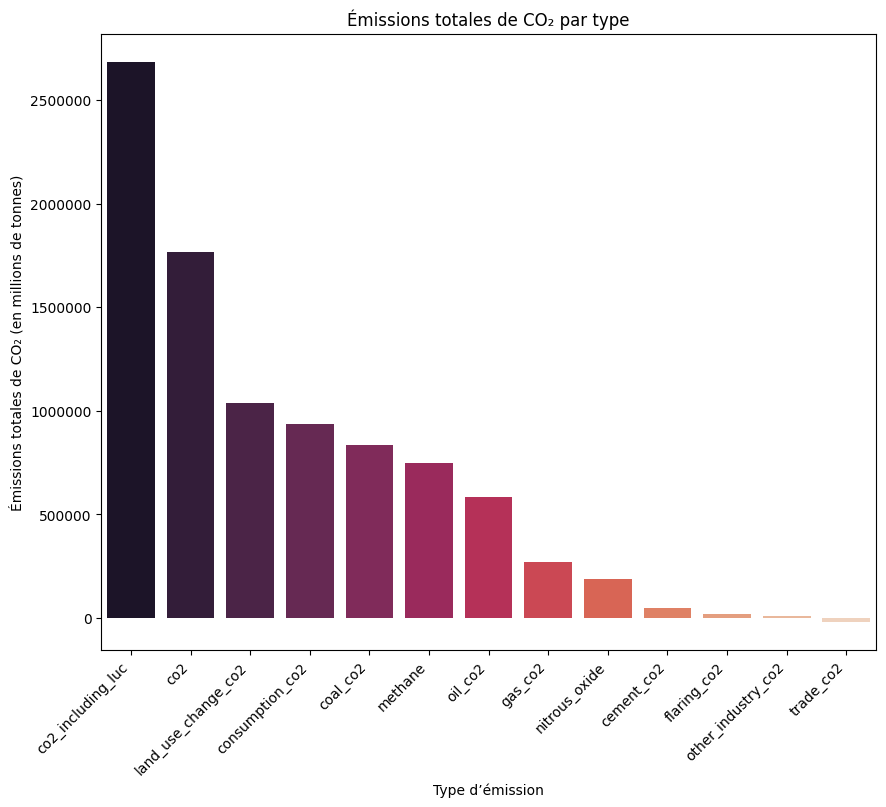

In [ ]:
# Répartitiion des gaz à effets de serres par continent
import matplotlib.pyplot as plt

# Sélection des données sur les 7 continents du monde
df_continent = df[df["country"].isin(["Africa", "Asia", "Europe", "Antarctica", "North America", "South America", "Australia"])]

# Un graphique avec la somme des émissions par type avec la même mesure tonnes
#Après voir s'il faut prendre les champs cumulatifs ou sans cumuls ou par personne
types_emissions = ["cement_co2", "co2","coal_co2","consumption_co2", "co2_including_luc","land_use_change_co2", "flaring_co2", "gas_co2", "methane", "nitrous_oxide", "oil_co2", "other_industry_co2","trade_co2"]
# Somme par type d'émission du gaz à effet de serre
somme_par_type = df_continent[types_emissions].sum().sort_values(ascending=False)
print(somme_par_type)

# Affichage du graphique
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.barplot(x=somme_par_type.index, y=somme_par_type.values, palette="rocket")

plt.xlabel("Type d’émission")
plt.ylabel("Émissions totales de CO₂ (en millions de tonnes)")
plt.title("Émissions totales de CO₂ par type")
plt.xticks(rotation=45, ha='right')  # pour lisibilité
# Supprime la notation scientifique
plt.ticklabel_format(style='plain', axis='y')
plt.show();


On remarque des émissions de CO2 annuelles avec le changement d'affectations des terres très élevées allant jusqu'à 2, 7 millions de tonnes, également du charbon  qui atteint les 845730 tonnes et méthane.
Cepandant, les émissions dues au commerces sont très basses, c'est peut être du au données manquantes car 90% des valeurs sont absentes. Est-ce que les commerces ne donnent pas leurs informations suur leur émissions ?


energy_per_capita                 1.132840e+07
ghg_per_capita                    1.486416e+04
co2_including_luc_per_capita      1.037231e+04
land_use_change_co2_per_capita    6.633958e+03
ghg_excluding_lucf_per_capita     5.475204e+03
co2_per_capita                    4.298461e+03
methane_per_capita                3.030904e+03
coal_co2_per_capita               2.319458e+03
consumption_co2_per_capita        1.465315e+03
oil_co2_per_capita                1.333953e+03
nitrous_oxide_per_capita          1.285466e+03
gas_co2_per_capita                5.297460e+02
cement_co2_per_capita             5.398400e+01
flaring_co2_per_capita            4.610200e+01
other_co2_per_capita              1.519900e+01
dtype: float64


/tmp/ipython-input-14-3116574679.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=somme_par_type_par_habitant.index, y=somme_par_type_par_habitant.values, palette="rocket")


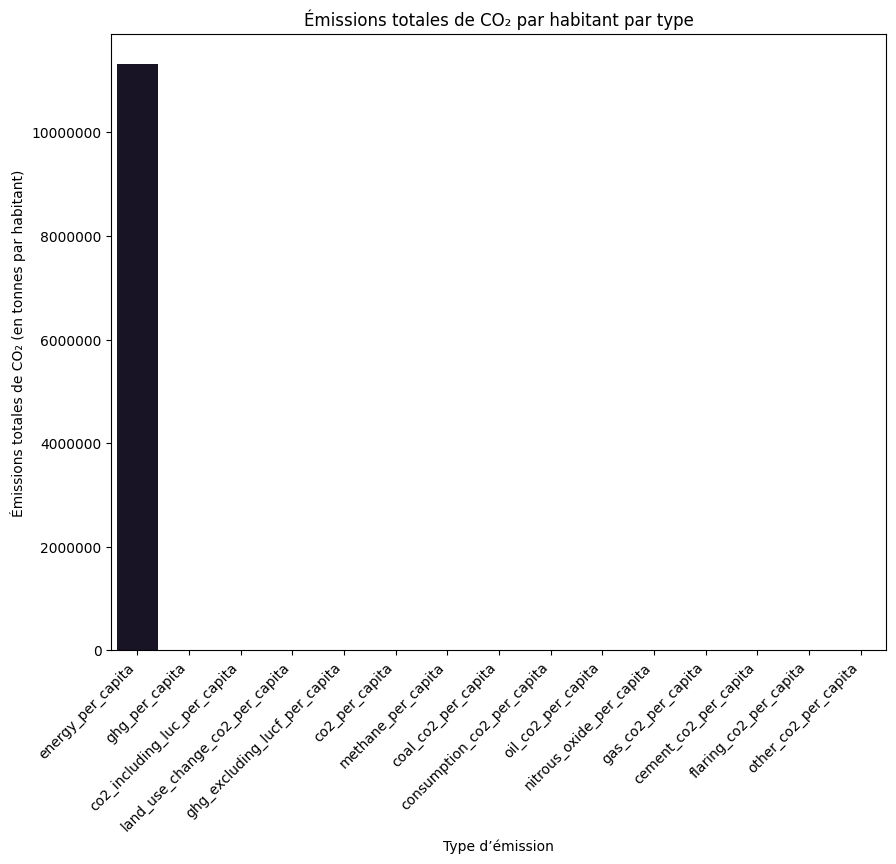

In [ ]:
# Les types d'émissions par personne
colonnes_capita = [col for col in df_continent.columns if "capita" in col]

# Somme par type d'émission du gaz à effet de serre par personne
somme_par_type_par_habitant = df_continent[colonnes_capita].sum().sort_values(ascending=False)
print(somme_par_type_par_habitant)

# Affichage du graphique
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.barplot(x=somme_par_type_par_habitant.index, y=somme_par_type_par_habitant.values, palette="rocket")

plt.xlabel("Type d’émission")
plt.ylabel("Émissions totales de CO₂ (en tonnes par habitant)")
plt.title("Émissions totales de CO₂ par habitant par type")
plt.xticks(rotation=45, ha='right')  # pour lisibilité
# Supprime la notation scientifique
plt.ticklabel_format(style='plain', axis='y')
plt.show();


cumulative_co2_including_luc                 1.363504e+08
cumulative_luc_co2                           8.388336e+07
cumulative_co2                               6.699577e+07
cumulative_coal_co2                          3.946153e+07
cumulative_oil_co2                           1.883414e+07
cumulative_gas_co2                           6.765691e+06
cumulative_cement_co2                        1.113855e+06
cumulative_flaring_co2                       5.957809e+05
cumulative_other_co2                         2.247128e+05
share_global_cumulative_coal_co2             2.738222e+04
share_global_cumulative_co2                  2.726583e+04
share_global_cumulative_luc_co2              2.251328e+04
share_global_cumulative_co2_including_luc    1.658483e+04
share_global_cumulative_oil_co2              1.650508e+04
share_global_cumulative_cement_co2           1.438300e+04
share_global_cumulative_gas_co2              1.419479e+04
share_global_cumulative_flaring_co2          7.395706e+03
share_global_c

/tmp/ipython-input-15-1935719583.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=somme_par_type_cumulative.index, y=somme_par_type_cumulative.values, palette="rocket")


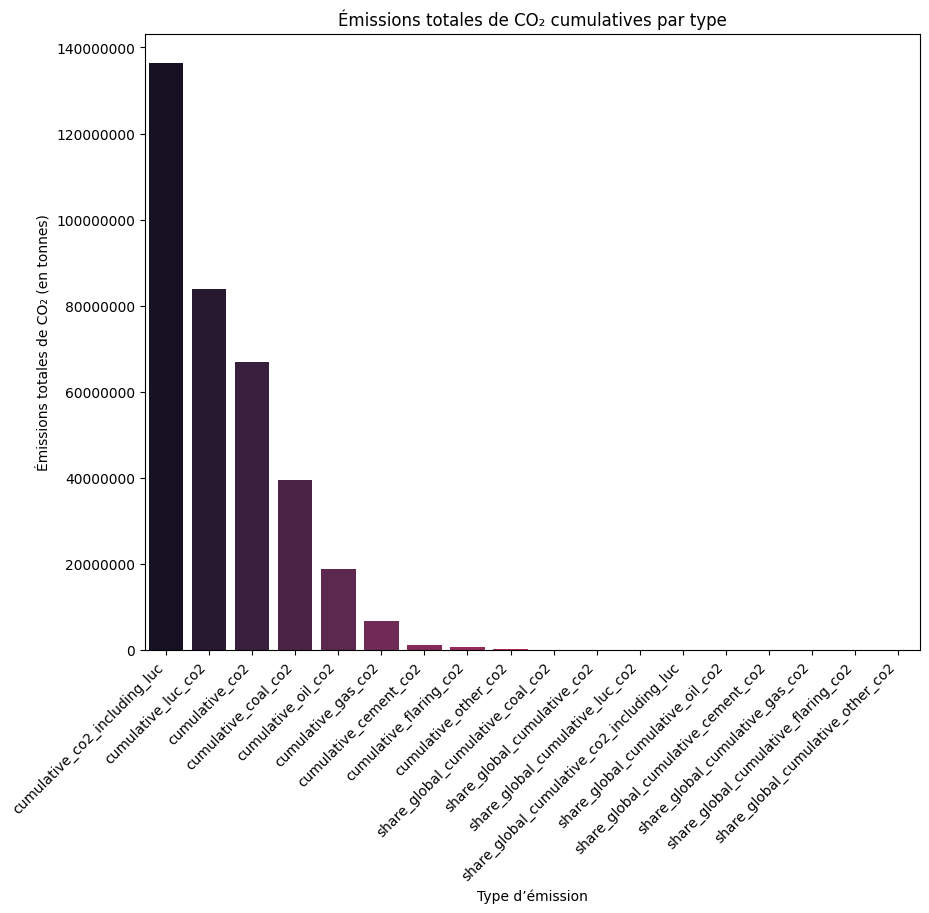

In [ ]:
# Les types d'émissions par personne
colonnes_cumulative = [col for col in df_continent.columns if "cumulative" in col]

# Somme par type d'émission du gaz à effet de serre par personne
somme_par_type_cumulative = df_continent[colonnes_cumulative].sum().sort_values(ascending=False)
print(somme_par_type_cumulative)

# Affichage du graphique
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.barplot(x=somme_par_type_cumulative.index, y=somme_par_type_cumulative.values, palette="rocket")

plt.xlabel("Type d’émission")
plt.ylabel("Émissions totales de CO₂ (en tonnes)")
plt.title("Émissions totales de CO₂ cumulatives par type")
plt.xticks(rotation=45, ha='right')  # pour lisibilité
# Supprime la notation scientifique
plt.ticklabel_format(style='plain', axis='y')
plt.show();


Les colonnes étant très nombreuse dans le jeu de données. Je vais me limiter sur les émissions annuelles mesurées en millions de tonnes qui sont plus informations en données et sont plus représentations.
types_emissions = ["cement_co2", "co2","coal_co2","consumption_co2", "co2_including_luc","land_use_change_co2", "flaring_co2", "gas_co2", "methane", "nitrous_oxide", "oil_co2", "other_industry_co2","trade_co2"]
Sur le graphique des émissions par personnes, les valeurs sont très basses.



In [ ]:
df_continent = df[df["country"].isin(["Africa", "Asia", "Europe", "Antarctica", "North America", "South America", "Australia"])]
# les colonnes à garder
df_continent2 = df_continent[["country", "year", "population", "gdp", "cement_co2", "co2","coal_co2", "co2_including_luc","land_use_change_co2", "flaring_co2", "gas_co2", "methane"
                              , "nitrous_oxide", "oil_co2", "other_industry_co2","trade_co2", "temperature_change_from_co2","temperature_change_from_ghg","temperature_change_from_n2o"]]
display(df_continent2.head())


,country,year,population,gdp,cement_co2,co2,coal_co2,co2_including_luc,land_use_change_co2,flaring_co2,gas_co2,methane,nitrous_oxide,oil_co2,other_industry_co2,trade_co2,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o
274,Africa,1750,80349715.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
275,Africa,1751,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
276,Africa,1752,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277,Africa,1753,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
278,Africa,1754,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Analyse et traitement des valeurs manquantes
# Colonnes avec peu de valeurs manquantes (NA < 30%), remplacement par la moyenne ou la médiane
# Champs population
# Calcul de la moyenne de population par pays
moy_pop = df_continent2.groupby("country")["population"].mean()
print(moy_pop)
df_continent2["population"] = df_continent2["population"].fillna(df_continent2["country"].map(moy_pop))
#Remplacer les valeurs manquantes de la population d'Antarctique par 0
df_continent2.loc[df_continent2["country"] == "Antarctica", "population"] = df_continent2.loc[df_continent2["country"] == "Antarctica", "population"].fillna(0)
print(df_continent2["population"].isna().sum())


print(df_continent2[["year","population"]])

# Après vérification utiliser la moyenne pour remplacer les valeurs manquantes n'est pas adaptée pour la population

country
Africa           3.007089e+08
Antarctica                NaN
Asia             1.579246e+09
Australia        7.120865e+06
Europe           4.526901e+08
North America    1.860455e+08
South America    1.123622e+08
Name: population, dtype: float64
0
       year    population
274    1750  8.034972e+07
275    1751  3.007089e+08
276    1752  3.007089e+08
277    1753  3.007089e+08
278    1754  3.007089e+08
279    1755  3.007089e+08
280    1756  3.007089e+08
281    1757  3.007089e+08
282    1758  3.007089e+08
283    1759  3.007089e+08
284    1760  8.086646e+07
285    1761  3.007089e+08
286    1762  3.007089e+08
287    1763  3.007089e+08
288    1764  3.007089e+08
289    1765  3.007089e+08
290    1766  3.007089e+08
291    1767  3.007089e+08
292    1768  3.007089e+08
293    1769  3.007089e+08
294    1770  8.145662e+07
295    1771  3.007089e+08
296    1772  3.007089e+08
297    1773  3.007089e+08
298    1774  3.007089e+08
299    1775  3.007089e+08
300    1776  3.007089e+08
301    1777  3.0070

/tmp/ipython-input-17-4125326405.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_continent2["population"] = df_continent2["population"].fillna(df_continent2["country"].map(moy_pop))


In [ ]:
# l’interpolation chronologique par pays pour remplacer les valeurs manquantes de population
# Trie des données par pays et par année
df_continent3 = df_continent[["country", "year", "population", "gdp", "cement_co2", "co2","coal_co2", "co2_including_luc","land_use_change_co2", "flaring_co2", "gas_co2", "methane"
                              , "nitrous_oxide", "oil_co2", "total_ghg","total_ghg_excluding_lucf", "temperature_change_from_co2","temperature_change_from_ghg","temperature_change_from_n2o","temperature_change_from_ch4"]]
df_continent3 = df_continent3.sort_values(by=["country", "year"])

# Interpolation linéaire de la population par pays
df_continent3["population"] = df_continent3.groupby("country")["population"].transform(lambda x: x.interpolate(method='linear'))
print(df_continent3[["year","population"]])
df_continent3.loc[df_continent3["country"] == "Antarctica", "population"] = df_continent3.loc[df_continent3["country"] == "Antarctica", "population"].fillna(0)
print(df_continent3["population"].isna().sum())

       year    population
274    1750  8.034972e+07
275    1751  8.040139e+07
276    1752  8.045306e+07
277    1753  8.050474e+07
278    1754  8.055641e+07
279    1755  8.060809e+07
280    1756  8.065976e+07
281    1757  8.071144e+07
282    1758  8.076311e+07
283    1759  8.081479e+07
284    1760  8.086646e+07
285    1761  8.092548e+07
286    1762  8.098449e+07
287    1763  8.104351e+07
288    1764  8.110252e+07
289    1765  8.116154e+07
290    1766  8.122055e+07
291    1767  8.127957e+07
292    1768  8.133859e+07
293    1769  8.139760e+07
294    1770  8.145662e+07
295    1771  8.152363e+07
296    1772  8.159065e+07
297    1773  8.165767e+07
298    1774  8.172469e+07
299    1775  8.179170e+07
300    1776  8.185872e+07
301    1777  8.192574e+07
302    1778  8.199276e+07
303    1779  8.205977e+07
304    1780  8.212679e+07
305    1781  8.217782e+07
306    1782  8.222885e+07
307    1783  8.227988e+07
308    1784  8.233091e+07
309    1785  8.238193e+07
310    1786  8.246698e+07
311    1787 

In [ ]:
# Remplacer les valeurs manquantes de temperature_change_from_co2 par la moyenne
moy_temp_co2 = df_continent3.groupby("country")["temperature_change_from_co2"].mean()
df_continent3["temperature_change_from_co2"] = df_continent3["temperature_change_from_co2"].fillna(df_continent3["country"].map(moy_temp_co2))
print(df_continent3["temperature_change_from_co2"].isna().sum())

moy_temp_ghg = df_continent3.groupby("country")["temperature_change_from_ghg"].mean()
df_continent3["temperature_change_from_ghg"] = df_continent3["temperature_change_from_ghg"].fillna(df_continent3["country"].map(moy_temp_ghg))
print(df_continent3["temperature_change_from_ghg"].isna().sum())

moy_temp_nitrate = df_continent3.groupby("country")["temperature_change_from_n2o"].mean()
df_continent3["temperature_change_from_n2o"] = df_continent3["temperature_change_from_n2o"].fillna(df_continent3["country"].map(moy_temp_nitrate))
df_continent3["temperature_change_from_n2o"] = df_continent3["temperature_change_from_n2o"].fillna(0)
print(df_continent3["temperature_change_from_n2o"].isna().sum())

moy_temp_methane = df_continent3.groupby("country")["temperature_change_from_ch4"].mean()
df_continent3["temperature_change_from_ch4"] = df_continent3["temperature_change_from_ch4"].fillna(df_continent3["country"].map(moy_temp_methane))
print(df_continent3[df_continent3["temperature_change_from_ch4"].isnull()])
df_continent3["temperature_change_from_ch4"] = df_continent3["temperature_change_from_ch4"].fillna(0)
print(df_continent3["temperature_change_from_ch4"].isna().sum())

# Aucune informations sur les types de température pour l'Antarctique, on remplaçait par 0


0
0
0
         country  year  population  gdp  cement_co2    co2  coal_co2  \
1692  Antarctica  1750         0.0  NaN         0.0    NaN       NaN   
1693  Antarctica  1751         0.0  NaN         0.0    NaN       NaN   
1694  Antarctica  1752         0.0  NaN         0.0    NaN       NaN   
1695  Antarctica  1753         0.0  NaN         0.0    NaN       NaN   
1696  Antarctica  1754         0.0  NaN         0.0    NaN       NaN   
1697  Antarctica  1755         0.0  NaN         0.0    NaN       NaN   
1698  Antarctica  1756         0.0  NaN         0.0    NaN       NaN   
1699  Antarctica  1757         0.0  NaN         0.0    NaN       NaN   
1700  Antarctica  1758         0.0  NaN         0.0    NaN       NaN   
1701  Antarctica  1759         0.0  NaN         0.0    NaN       NaN   
1702  Antarctica  1760         0.0  NaN         0.0    NaN       NaN   
1703  Antarctica  1761         0.0  NaN         0.0    NaN       NaN   
1704  Antarctica  1762         0.0  NaN         0.0    NaN

In [ ]:
# Remplacement des valeurs manquantes par la moyenne de certaines colonnes à garder pour le reste de l'analyse du jeu de données
colonnes_remplacement = ["cement_co2", "co2","coal_co2", "co2_including_luc","land_use_change_co2", "flaring_co"]
colonnes = ["coal_co2"]

for colonne in colonnes_remplacement:
    moy_colonne = df_continent3.groupby("country")[colonne].mean()
    df_continent3[colonne] = df_continent3[colonne].fillna(df_continent3["country"].map(moy_colonne))

    print(df_continent3[colonne].isna().sum())

moy_cement_co2 = df_continent3.groupby("country")["cement_co2"].mean()
df_continent3["cement_co2"] = df_continent3["cement_co2"].fillna(df_continent3["country"].map(moy_cement_co2))
print(df_continent3["cement_co2"].isna().sum())

moy_co2 = df_continent3.groupby("country")["co2"].mean()
df_continent3["co2"] = df_continent3["co2"].fillna(df_continent3["country"].map(moy_co2))
print(df_continent3["co2"].isna().sum())

moy_co2_including_luc = df_continent3.groupby("country")["co2_including_luc"].mean()
df_continent3["co2_including_luc"] = df_continent3["co2_including_luc"].fillna(df_continent3["country"].map(moy_co2_including_luc))
df_continent3["co2_including_luc"] = df_continent3["co2_including_luc"].fillna(0)
print(df_continent3["co2_including_luc"].isna().sum())

moy_coal_co2 = df_continent3.groupby("country")["coal_co2"].mean()
df_continent3["coal_co2"] = df_continent3["coal_co2"].fillna(df_continent3["country"].map(moy_coal_co2))
df_continent3["coal_co2"] = df_continent3["coal_co2"].fillna(0)
print(df_continent3["coal_co2"].isna().sum())

moy_flaring_co2 = df_continent3.groupby("country")["flaring_co2"].mean()
df_continent3["flaring_co2"] = df_continent3["flaring_co2"].fillna(df_continent3["country"].map(moy_flaring_co2))
print(df_continent3["flaring_co2"].isna().sum())

moy_gas_co2 = df_continent3.groupby("country")["gas_co2"].mean()
df_continent3["gas_co2"] = df_continent3["flaring_co2"].fillna(df_continent3["country"].map(moy_gas_co2))
print(df_continent3["gas_co2"].isna().sum())

moy_methane = df_continent3.groupby("country")["methane"].mean()
df_continent3["methane"] = df_continent3["methane"].fillna(df_continent3["country"].map(moy_methane))
df_continent3["methane"] = df_continent3["methane"].fillna(0)
print(df_continent3["methane"].isna().sum())

moy_nitrous_oxide = df_continent3.groupby("country")["nitrous_oxide"].mean()
df_continent3["nitrous_oxide"] = df_continent3["nitrous_oxide"].fillna(df_continent3["country"].map(moy_nitrous_oxide))
df_continent3["nitrous_oxide"] = df_continent3["nitrous_oxide"].fillna(0)
print(df_continent3["nitrous_oxide"].isna().sum())

moy_oil_co2 = df_continent3.groupby("country")["oil_co2"].mean()
df_continent3["oil_co2"] = df_continent3["oil_co2"].fillna(df_continent3["country"].map(moy_oil_co2))
print(df_continent3["oil_co2"].isna().sum())

moy_total_ghg = df_continent3.groupby("country")["total_ghg"].mean()
df_continent3["total_ghg"] = df_continent3["total_ghg"].fillna(df_continent3["country"].map(moy_total_ghg))
df_continent3["total_ghg"] = df_continent3["total_ghg"].fillna(0)
print(df_continent3["total_ghg"].isna().sum())

moy_total_ghg_excluding_lucf = df_continent3.groupby("country")["total_ghg_excluding_lucf"].mean()
df_continent3["total_ghg_excluding_lucf"] = df_continent3["total_ghg_excluding_lucf"].fillna(df_continent3["country"].map(moy_total_ghg_excluding_lucf))
df_continent3["total_ghg_excluding_lucf"] = df_continent3["total_ghg_excluding_lucf"].fillna(0)
print(df_continent3["total_ghg_excluding_lucf"].isna().sum())





0
0
0
0
0
0
0
0
0
0
0


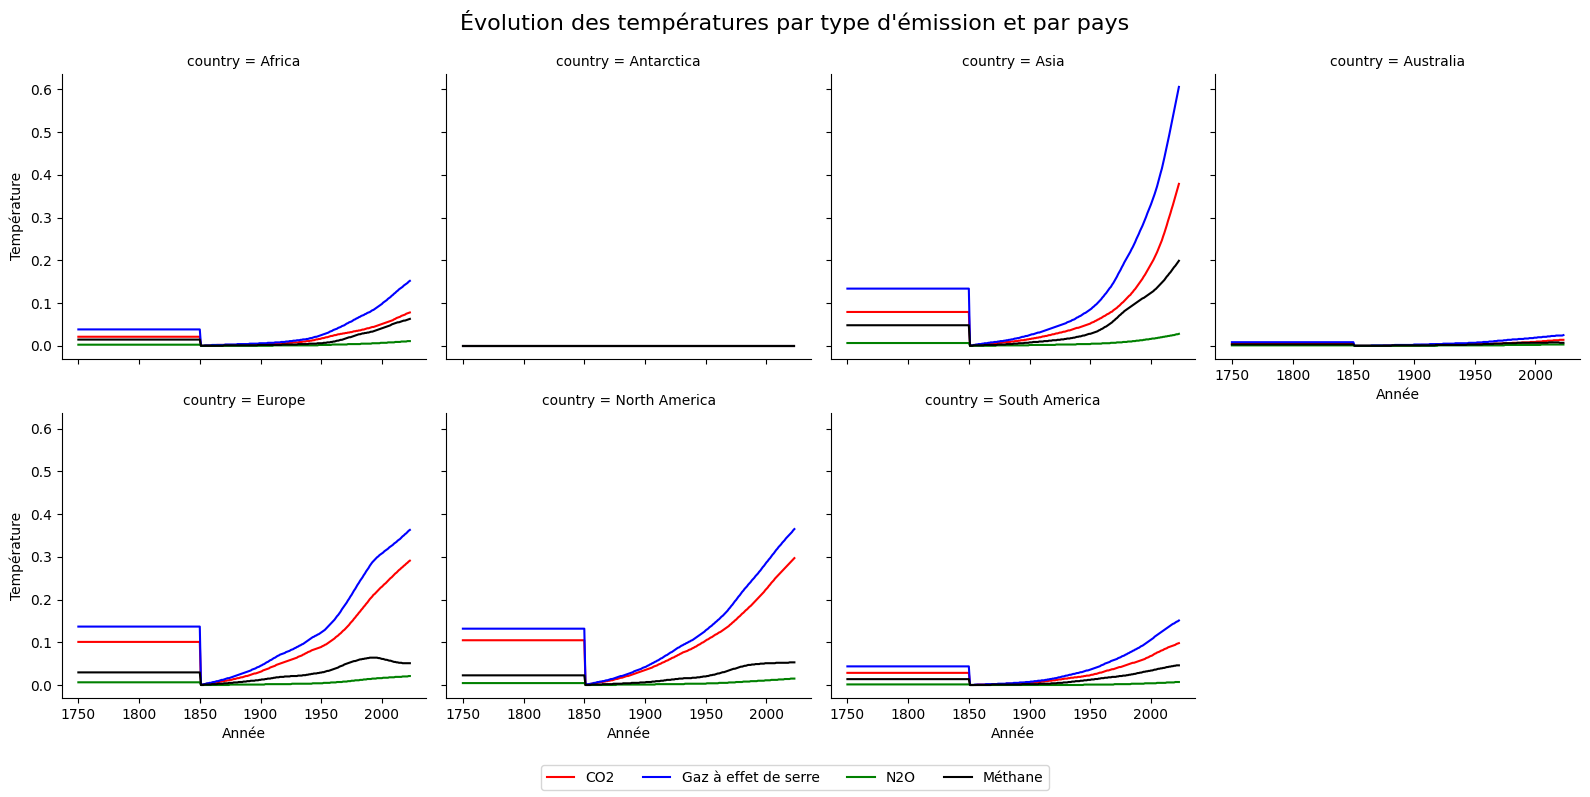

In [ ]:
# Fonction de tracé avec labels
def multi_line_plot(data, **kwargs):
    plt.plot(data["year"], data["temperature_change_from_co2"], color="red", label="CO2")
    plt.plot(data["year"], data["temperature_change_from_ghg"], color="blue", label="Gaz à effet de serre")
    plt.plot(data["year"], data["temperature_change_from_n2o"], color="green", label="N2O")
    plt.plot(data["year"], data["temperature_change_from_ch4"], color="black", label="Méthane")

# Création du FacetGrid
g = sns.FacetGrid(df_continent3, col="country", col_wrap=4, height=4, sharey=True)

# Tracé
g.map_dataframe(multi_line_plot)

# Titre des axes
g.set_ylabels("Température")
g.set_xlabels("Année")

# Récupération automatique des éléments de légende depuis le premier axe
handles, labels = g.axes[0].get_legend_handles_labels()
g.fig.legend(handles=handles, labels=labels, loc='lower center', ncol=4, fontsize='medium')

# Titre global et ajustement des marges
g.fig.suptitle("Évolution des températures par type d'émission et par pays", fontsize=16)
g.tight_layout()
g.fig.subplots_adjust(top=0.9, bottom=0.12)

plt.show();


On remarque que les températures dues aux gaz à effet de serres augmentent au fil des années sur l'ensemble des continents. Ces augmentations sont plus grandes en Asie, Europe et Amérique du Nord,
Une augmenation légère est visible au niveau de l'Afrique, Amérique du Nord et une constante au niveau de l'Antarctique.


/tmp/ipython-input-22-2199464772.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_continent3["total_co2_sources"] = df_continent3[co2_cols].sum(axis=1)


<Figure size 1200x800 with 0 Axes>

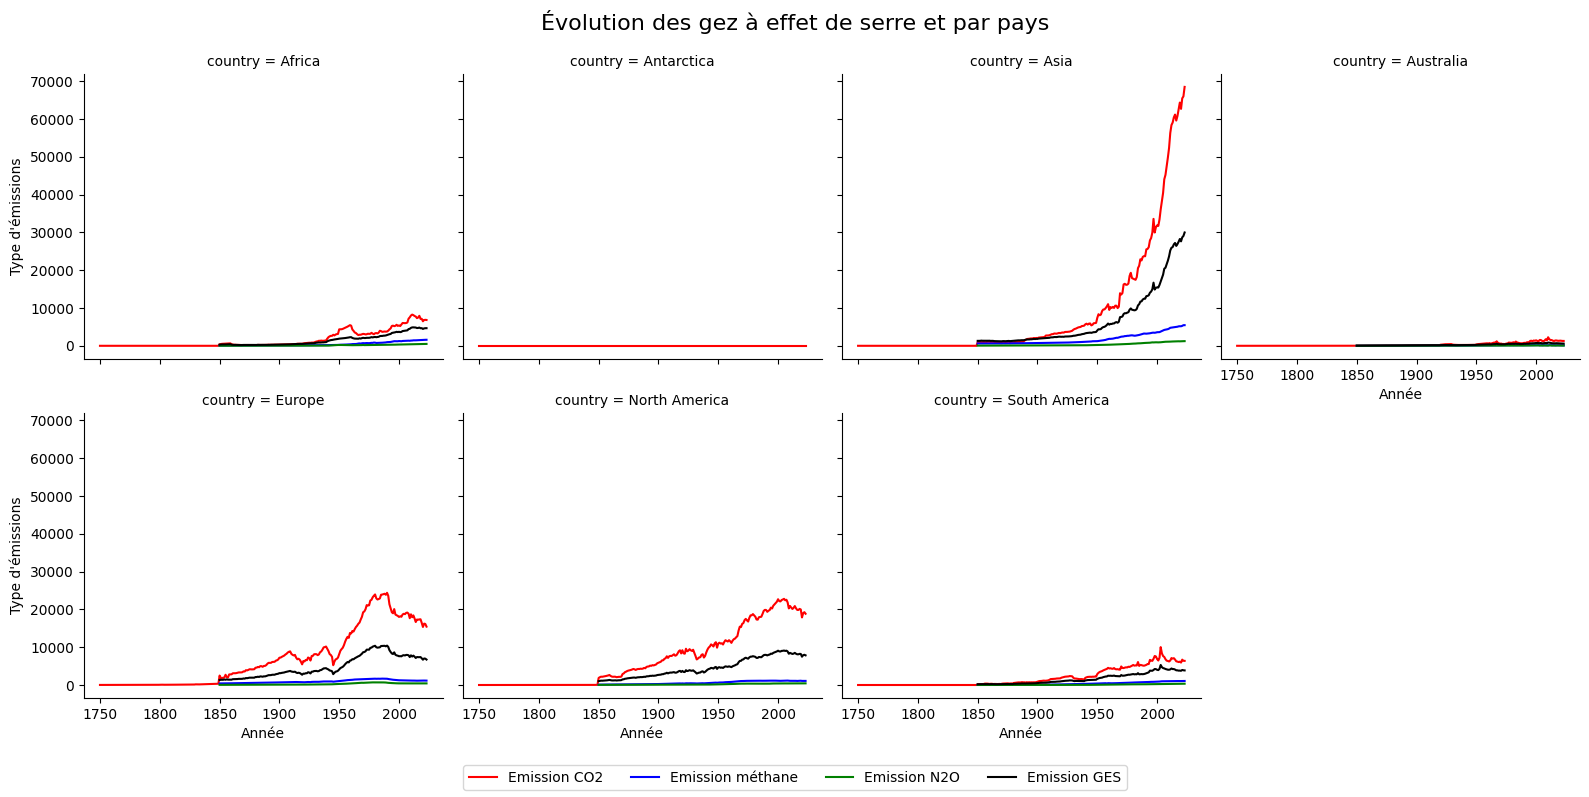

In [ ]:
# Voir l'évolution des types d'émissions de gaz à effets de serre au niveau des continent et au fil des années
# Je vais regrouper les types d'émissions de CO2 ensemble
df_continent3 = df_continent[["country", "year", "population", "gdp", "cement_co2", "co2","coal_co2", "co2_including_luc","land_use_change_co2", "flaring_co2", "gas_co2", "methane"
                              , "nitrous_oxide", "oil_co2", "total_ghg","total_ghg_excluding_lucf", "temperature_change_from_co2","temperature_change_from_ghg","temperature_change_from_n2o","temperature_change_from_ch4"]]
# créer une seule colonne avec le total de toutes les colonnes "CO2

# Sélectionner toutes les colonnes contenant "co2"
co2_cols = [col for col in df_continent3.columns if "co2" in col.lower()]
# Créer une nouvelle colonne avec la somme de toutes les colonnes CO2
df_continent3["total_co2_sources"] = df_continent3[co2_cols].sum(axis=1)
plt.figure(figsize=(12, 8))
# Fonction de tracé avec labels
def multi_line_plot(data, **kwargs):
    plt.plot(data["year"], data["total_co2_sources"], color="red", label="Emission CO2")
    plt.plot(data["year"], data["methane"], color="blue", label="Emission méthane")
    plt.plot(data["year"], data["nitrous_oxide"], color="green", label="Emission N2O")
    plt.plot(data["year"], data["total_ghg"], color="black", label="Emission GES")

# Création du FacetGrid
g = sns.FacetGrid(df_continent3, col="country", col_wrap=4, height=4, sharey=True)

# Tracé
g.map_dataframe(multi_line_plot)

# Titre des axes
g.set_ylabels("Type d'émissions")
g.set_xlabels("Année")

# Récupération automatique des éléments de légende depuis le premier axe
handles, labels = g.axes[0].get_legend_handles_labels()
g.fig.legend(handles=handles, labels=labels, loc='lower center', ncol=4, fontsize='medium')

# Titre global et ajustement des marges
g.fig.suptitle("Évolution des gez à effet de serre et par pays", fontsize=16)
g.tight_layout()
g.fig.subplots_adjust(top=0.9, bottom=0.12)

plt.show();



On constate une augmentation des types d'émisions des gaz à effet de serre à partir des années 1850. Une évolution plus fulgurante des types d'émission en Asie, suivi de l'Europ et l'Amérique du Nord. L'émission des types de CO2 est très basse en Afrique et l'Amérique du Sud.
Les courbes d'émissions très similaires au fil des années de 1750 à 2025 en Antartica.
Pourra-on dire que les pays les plus développées émettent plus de CO2 et de gaz à effet serre ?
Pour confirmer cela, on va faire une graphique de ces émissions en fonction du PIB de chaque continent. Mais les PIB en sont pas remplis pour les continents.
Donc je vais voir si la nombre d'habitants dans le continent a un role sur la le taux d'émissions de CO2 qui est le gaz qui contribue le plus sur le réchauffement climatique. Cela s'est confirmé à travers les visuels.

         country    population  total_co2_sources
1     Antarctica  0.000000e+00              0.314
3      Australia  1.630678e+09          87224.990
6  South America  2.595566e+10         518114.330
5  North America  4.297650e+10        1899390.314
0         Africa  6.946376e+10         435555.572
4         Europe  1.045714e+11        1939956.445
2           Asia  3.648059e+11        2360675.838


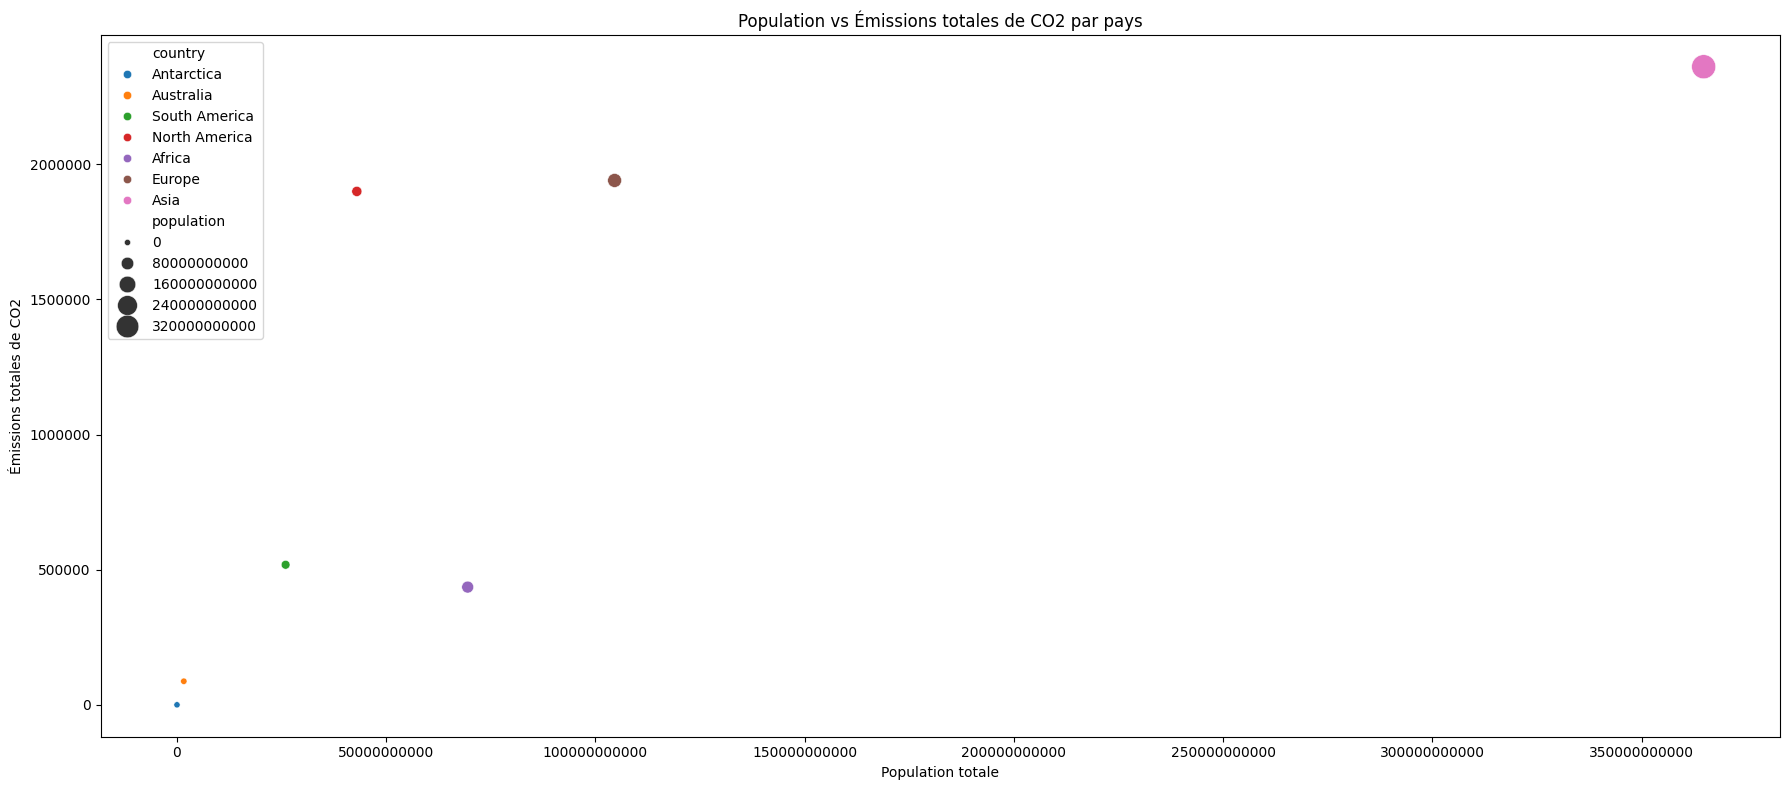

In [ ]:
# Regrouper les données par continent
df_continent_agg = df_continent3.groupby("country").agg({"population": "sum","total_co2_sources": "sum"}).reset_index()
df_continent_agg = df_continent_agg.sort_values(by = ["population", "total_co2_sources"])
print(df_continent_agg)

plt.figure(figsize=(18, 8))

# Création du graphique
sns.scatterplot(
    data=df_continent_agg,
    x="population",
    y="total_co2_sources",
    hue="country",
    size="population",
    sizes=(20, 300),
)



# Titres et axes
plt.title("Population vs Émissions totales de CO2 par pays")
plt.xlabel("Population totale")
plt.ylabel("Émissions totales de CO2")
plt.ticklabel_format(style='plain', axis='x') # pour supprimer les chiffres qui débordent sur les axes
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()